<a href="https://colab.research.google.com/github/sanjana05111/NeuroNexus/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original class distribution:
 Class
0.0    15369
1.0       73
Name: count, dtype: int64


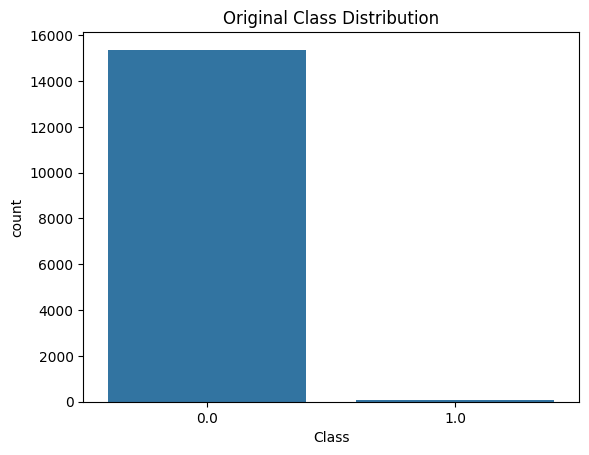


Logistic Regression - Confusion Matrix:
[[3071    1]
 [   7   10]]

Decision Tree Classifier - Confusion Matrix:
[[3072    0]
 [   1   16]]

Random Forest Classifier - Confusion Matrix:
[[3072    0]
 [   1   16]]

===== Imbalanced Data =====
                      Model  Accuracy  Precision    Recall  F1 Score
0       Logistic Regression  0.997410   0.909091  0.588235  0.714286
1  Decision Tree Classifier  0.999676   1.000000  0.941176  0.969697
2  Random Forest Classifier  0.999676   1.000000  0.941176  0.969697

Logistic Regression - Confusion Matrix:
[[17  0]
 [ 1 12]]

Decision Tree Classifier - Confusion Matrix:
[[16  1]
 [ 1 12]]

Random Forest Classifier - Confusion Matrix:
[[17  0]
 [ 1 12]]

===== Undersampled Data =====
                      Model  Accuracy  Precision    Recall  F1 Score
0       Logistic Regression  0.966667   1.000000  0.923077  0.960000
1  Decision Tree Classifier  0.933333   0.923077  0.923077  0.923077
2  Random Forest Classifier  0.966667   1.000000  0.9

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib
data = pd.read_csv("creditcard.csv", on_bad_lines='skip')
pd.options.display.max_columns = None
sc = StandardScaler()
data['Amount'] = sc.fit_transform(pd.DataFrame(data['Amount']))
data = data.drop(['Time'], axis=1)
data = data.drop_duplicates()
print("Original class distribution:\n", data['Class'].value_counts())
sns.countplot(x='Class', data=data)
plt.title("Original Class Distribution")
plt.show()
def evaluate_models(X, y, title="Model Evaluation"):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    classifiers = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree Classifier": DecisionTreeClassifier(max_depth=10),
        "Random Forest Classifier": RandomForestClassifier(n_estimators=50, max_depth=10)
    }

    results = []

    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1 Score': f1_score(y_test, y_pred)
        })

        print(f"\n{name} - Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

    print(f"\n===== {title} =====")
    result_df = pd.DataFrame(results)
    print(result_df)
X = data.drop('Class', axis=1)
y = data['Class']
X = X.fillna(X.mean())
X = data.drop('Class', axis=1)
y = data['Class']
X = X.fillna(X.mean())
if y.isnull().any():
    non_nan_indices = y.dropna().index
    X = X.loc[non_nan_indices]
    y = y.loc[non_nan_indices]

evaluate_models(X, y, title="Imbalanced Data")
normal = data[data['Class'] == 0]
fraud = data[data['Class'] == 1]
normal_sample = normal.sample(n=len(fraud), random_state=42)
undersampled_data = pd.concat([normal_sample, fraud], ignore_index=True)

X_under = undersampled_data.drop('Class', axis=1)
y_under = undersampled_data['Class']

evaluate_models(X_under, y_under, title="Undersampled Data")
X_res, y_res = SMOTE(random_state=42).fit_resample(X, y)
print("\nSMOTE class distribution:\n", y_res.value_counts())
evaluate_models(X_res, y_res, title="SMOTE Oversampled Data")
final_model = DecisionTreeClassifier()
final_model.fit(X_res, y_res)
joblib.dump(final_model, "credit_card_model.pkl")
print("\n Model saved as credit_card_model.pkl")
model = joblib.load("credit_card_model.pkl")

sample_input = [[
    -1.3598071336738,-0.0727811733098497,2.53634673796914,1.37815522427443,
    -0.338320769942518,0.462387777762292,0.239598554061257,0.0986979012610507,
    0.363786969611213,0.0907941719789316,-0.551599533260813,-0.617800855762348,
    -0.991389847235408,-0.311169353699879,1.46817697209427,-0.470400525259478,
    0.207971241929242,0.0257905801985591,0.403992960255733,0.251412098239705,
    -0.018306777944153,0.277837575558899,-0.110473910188767,0.0669280749146731,
    0.128539358273528,-0.189114843888824,0.133558376740387,-0.0210530534538215,
    149.62
]]

prediction = model.predict(sample_input)
print("\n Sample Prediction:")
print("Fraud Transaction" if prediction[0] == 1 else "Normal Transaction")

